# Dismounted Commander's Associate — Tactical Activity Recognition
## Rwanda Defence Force (RDF) | R&D Prototype v0.2

**Objective:** Train a model that classifies a dismounted soldier's tactical state from accelerometer and gyroscope data collected on a ruggedized Android tablet. The model must be lightweight enough to run **on-device (edge)** with no network dependency.

### Tactical States to Predict
| Label | Description |
|---|---|
| `WALKING` | Tactical movement on foot |
| `RUNNING` | Fast movement / breaking cover |
| `CRAWLING` | Low-profile infiltration *(no dataset available — future work)* |
| `PRONE_STILL` | Lying flat, taking cover / possible distress |
| `KNEELING_READY` | Stationary but alert (kneeling or standing) |

### Datasets
Two sensor datasets are merged to cover all trainable classes:

| Dataset | Classes Used | Source |
|---|---|---|
| **UCI HAR** | WALKING, KNEELING_READY, PRONE_STILL | 561-feature windows + 9-ch raw signals @ 50 Hz |
| **MotionSense** | WALKING, **RUNNING**, KNEELING_READY | 12-ch raw IMU signals @ 50 Hz (iPhone 6s) |

**Common sensor channel alignment (6 channels used for LSTM):**

| Unified Channel | UCI HAR Source | MotionSense Source |
|---|---|---|
| acc_x/y/z | `body_acc_x/y/z` | `userAcceleration.x/y/z` |
| gyro_x/y/z | `body_gyro_x/y/z` | `rotationRate.x/y/z` |

> ⚠️ **Prototype Gap:** `CRAWLING` has no satisfactory counterpart in either civilian dataset. Collecting labelled military exercise data remains the highest-priority next step before operational deployment.


## Section 1 — Import Required Libraries

In [34]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {keras.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")


TensorFlow  : 2.20.0
Keras       : 3.13.2
NumPy       : 2.4.2
Pandas      : 3.0.1
Scikit-learn: 1.8.0


## Section 2 — Load UCI HAR Dataset


In [35]:
# ─── Paths ────────────────────────────────────────────────────────────────────
DATASET_UCI_PATH = os.path.join('..', 'UCI HAR Dataset')
TRAIN_PATH       = os.path.join(DATASET_UCI_PATH, 'train')
TEST_PATH        = os.path.join(DATASET_UCI_PATH, 'test')

# ─── Load feature names ───────────────────────────────────────────────────────
features = pd.read_csv(
    os.path.join(DATASET_UCI_PATH, 'features.txt'),
    sep=r'\s+', header=None, names=['idx', 'feature']
)
feature_names = features['feature'].tolist()

# De-duplicate feature names (UCI HAR has some duplicates)
seen = {}
unique_names = []
for name in feature_names:
    if name in seen:
        seen[name] += 1
        unique_names.append(f"{name}_{seen[name]}")
    else:
        seen[name] = 0
        unique_names.append(name)

# ─── Load feature matrices (561 features) ─────────────────────────────────────
X_uci_train_feats = pd.read_csv(os.path.join(TRAIN_PATH, 'X_train.txt'),
                                 sep=r'\s+', header=None, names=unique_names)
X_uci_test_feats  = pd.read_csv(os.path.join(TEST_PATH,  'X_test.txt'),
                                 sep=r'\s+', header=None, names=unique_names)

# ─── Load labels ──────────────────────────────────────────────────────────────
y_train_raw = pd.read_csv(os.path.join(TRAIN_PATH, 'y_train.txt'),
                           header=None, names=['activity_id'])
y_test_raw  = pd.read_csv(os.path.join(TEST_PATH,  'y_test.txt'),
                           header=None, names=['activity_id'])

# ─── Load subject IDs ─────────────────────────────────────────────────────────
subj_uci_train = pd.read_csv(os.path.join(TRAIN_PATH, 'subject_train.txt'),
                              header=None, names=['subject_id'])
subj_uci_test  = pd.read_csv(os.path.join(TEST_PATH,  'subject_test.txt'),
                              header=None, names=['subject_id'])

# ─── UCI activity map → tactical labels ──────────────────────────────────────
UCI_ACTIVITY_MAP = {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
                    4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}
UCI_TACTICAL_MAP = {
    'WALKING':            'WALKING',
    'WALKING_UPSTAIRS':   'WALKING',
    'WALKING_DOWNSTAIRS': 'WALKING',
    'SITTING':            'KNEELING_READY',
    'STANDING':           'KNEELING_READY',
    'LAYING':             'PRONE_STILL',
}

y_uci_train = y_train_raw['activity_id'].map(UCI_ACTIVITY_MAP).map(UCI_TACTICAL_MAP)
y_uci_test  = y_test_raw['activity_id'].map(UCI_ACTIVITY_MAP).map(UCI_TACTICAL_MAP)

# ─── Load raw 6-channel inertial signals (body_acc + body_gyro only) ──────────
# Dropping total_acc to match the MotionSense channel set for the LSTM.
def load_uci_6ch(split: str) -> np.ndarray:
    """Load body_acc (xyz) + body_gyro (xyz) → shape (N, 128, 6)."""
    base = os.path.join(DATASET_UCI_PATH, split, 'Inertial Signals')
    channels = [
        f'body_acc_x_{split}.txt',  f'body_acc_y_{split}.txt',  f'body_acc_z_{split}.txt',
        f'body_gyro_x_{split}.txt', f'body_gyro_y_{split}.txt', f'body_gyro_z_{split}.txt',
    ]
    arrays = [pd.read_csv(os.path.join(base, ch), sep=r'\s+', header=None).values
              for ch in channels]
    return np.stack(arrays, axis=-1).astype(np.float32)   # (N, 128, 6)

print("Loading UCI HAR raw signals (6 channels) …")
X_uci_raw_train = load_uci_6ch('train')   # (7352, 128, 6)
X_uci_raw_test  = load_uci_6ch('test')    # (2947, 128, 6)

print("=== UCI HAR Dataset Shape ===")
print(f"Feature matrix   : train {X_uci_train_feats.shape}  |  test {X_uci_test_feats.shape}")
print(f"Raw windows (6ch): train {X_uci_raw_train.shape}    |  test {X_uci_raw_test.shape}")
print(f"\nTraining subjects : {sorted(subj_uci_train['subject_id'].unique())}")
print(f"Test subjects     : {sorted(subj_uci_test['subject_id'].unique())}")
print("\n--- UCI Tactical Class Counts (train) ---")
print(y_uci_train.value_counts())


Loading UCI HAR raw signals (6 channels) …
=== UCI HAR Dataset Shape ===
Feature matrix   : train (7352, 561)  |  test (2947, 561)
Raw windows (6ch): train (7352, 128, 6)    |  test (2947, 128, 6)

Training subjects : [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Test subjects     : [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]

--- UCI Tactical Class Counts (train) ---
activity_id
WALKING           3285
KNEELING_READY    2660
PRONE_STILL       1407
Name: count, dtype: int64


## Section 3 — Load & Window MotionSense Dataset

MotionSense provides raw time-series at 50 Hz with 12 channels per sample. We extract the 6 channels that align with UCI HAR (`userAcceleration` xyz → `body_acc`, `rotationRate` xyz → `body_gyro`) and apply the same 128-sample / 50%-overlap sliding window used by UCI HAR.

**Expected path:** `../MotionSense Dataset/A_DeviceMotion_data/`

Download from: https://www.kaggle.com/datasets/malekzadeh/motionsense-dataset


In [36]:
# ─── MotionSense dataset path ─────────────────────────────────────────────────
DATASET_MS_PATH = os.path.join('..', 'MotionSense Dataset')
MS_DATA_PATH    = os.path.join(DATASET_MS_PATH, 'A_DeviceMotion_data')

# ─── Label mapping: MotionSense activity prefix → tactical label ──────────────
MS_TACTICAL_MAP = {
    'dws': 'WALKING',         # downstairs — hilly terrain movement
    'ups': 'WALKING',         # upstairs   — hilly terrain movement
    'wlk': 'WALKING',         # walking
    'jog': 'RUNNING',         # jogging    — the key new class
    'sit': 'KNEELING_READY',  # sitting
    'std': 'KNEELING_READY',  # standing
}

WIN_SIZE  = 128   # matches UCI HAR (2.56 s @ 50 Hz)
WIN_STEP  = 64    # 50% overlap

# ─── Loaders ──────────────────────────────────────────────────────────────────
def load_motionsense(data_path: str, win_size: int = 128, step: int = 64):
    """
    Walk A_DeviceMotion_data/, window each subject's time-series,
    extract the 6 common channels (userAcceleration xyz + rotationRate xyz).
    Returns: windows (N, 128, 6), labels (N,), subjects (N,)
    """
    ACC_COLS  = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
    GYRO_COLS = ['rotationRate.x',     'rotationRate.y',     'rotationRate.z']
    COLS      = ACC_COLS + GYRO_COLS

    all_windows, all_labels, all_subjects = [], [], []

    if not os.path.exists(data_path):
        print(f"⚠️  MotionSense data path not found: {data_path}")
        print("    Place the dataset at '../MotionSense Dataset/A_DeviceMotion_data/'")
        print("    Returning empty arrays — UCI HAR only training will continue.")
        return (np.empty((0, win_size, 6), dtype=np.float32),
                np.array([]), np.array([]))

    for folder in sorted(os.listdir(data_path)):
        folder_path = os.path.join(data_path, folder)
        if not os.path.isdir(folder_path):
            continue
        act_prefix = folder.split('_')[0]          # e.g. 'dws_1' → 'dws'
        if act_prefix not in MS_TACTICAL_MAP:
            continue
        tactical_label = MS_TACTICAL_MAP[act_prefix]

        for csv_file in sorted(os.listdir(folder_path)):
            if not csv_file.endswith('.csv'):
                continue
            # Filename: sub_1.csv → subject 1
            try:
                subj_id = int(csv_file.replace('sub_', '').replace('.csv', ''))
            except ValueError:
                continue

            df = pd.read_csv(os.path.join(folder_path, csv_file))
            if not all(c in df.columns for c in COLS):
                continue

            signal = df[COLS].values.astype(np.float32)   # (T, 6)
            n = len(signal)
            start = 0
            while start + win_size <= n:
                all_windows.append(signal[start:start + win_size])
                all_labels.append(tactical_label)
                all_subjects.append(subj_id)
                start += step

    if not all_windows:
        print("⚠️  No MotionSense windows extracted — check data path / folder structure.")
        return (np.empty((0, win_size, 6), dtype=np.float32),
                np.array([]), np.array([]))

    return (np.array(all_windows, dtype=np.float32),
            np.array(all_labels),
            np.array(all_subjects, dtype=int))


# ─── Load ─────────────────────────────────────────────────────────────────────
print("Loading MotionSense …")
X_ms_raw, y_ms_labels, subj_ms = load_motionsense(MS_DATA_PATH, WIN_SIZE, WIN_STEP)

if len(X_ms_raw) > 0:
    # Subject-based train/test split: subjects 1-20 → train, 21-24 → test
    TRAIN_SUBJ = set(range(1, 21))
    ms_train_idx = np.where(np.isin(subj_ms, list(TRAIN_SUBJ)))[0]
    ms_test_idx  = np.where(~np.isin(subj_ms, list(TRAIN_SUBJ)))[0]

    X_ms_raw_train = X_ms_raw[ms_train_idx]
    X_ms_raw_test  = X_ms_raw[ms_test_idx]
    y_ms_train     = y_ms_labels[ms_train_idx]
    y_ms_test      = y_ms_labels[ms_test_idx]

    print(f"MotionSense windows — train: {X_ms_raw_train.shape}  |  test: {X_ms_raw_test.shape}")
    print("\nMotionSense tactical class counts (train):")
    for lbl, cnt in sorted(pd.Series(y_ms_train).value_counts().items()):
        print(f"  {lbl:<16} : {cnt}")
    print("\nMotionSense tactical class counts (test):")
    for lbl, cnt in sorted(pd.Series(y_ms_test).value_counts().items()):
        print(f"  {lbl:<16} : {cnt}")
else:
    # Create empty placeholders so the rest of the notebook still runs on UCI only
    X_ms_raw_train = np.empty((0, WIN_SIZE, 6), dtype=np.float32)
    X_ms_raw_test  = np.empty((0, WIN_SIZE, 6), dtype=np.float32)
    y_ms_train     = np.array([])
    y_ms_test      = np.array([])
    print("Running UCI HAR only (no MotionSense data found).")


Loading MotionSense …
MotionSense windows — train: (18027, 128, 6)  |  test: (3512, 128, 6)

MotionSense tactical class counts (train):
  KNEELING_READY   : 8375
  RUNNING          : 1677
  WALKING          : 7975

MotionSense tactical class counts (test):
  KNEELING_READY   : 1562
  RUNNING          : 348
  WALKING          : 1602


## Section 4 — Merge Datasets & Visualise Class Distribution

Raw 6-channel windows from both datasets (UCI HAR and MotionSense) are concatenated into a single training pool. Subject-based splits are preserved — no subject appears in both train and test.

| UCI HAR Activity | → Tactical Label | MotionSense Activity | → Tactical Label |
|---|---|---|---|
| WALKING / _UPSTAIRS / _DOWNSTAIRS | `WALKING` | wlk / dws / ups | `WALKING` |
| SITTING / STANDING | `KNEELING_READY` | sit / std | `KNEELING_READY` |
| LAYING | `PRONE_STILL` | *(not available)* | — |
| *(not available)* | — | jog | **`RUNNING`** |


=== Merged Dataset ===
Train windows : (25379, 128, 6)
Test  windows : (6459, 128, 6)

Tactical classes: ['KNEELING_READY', 'PRONE_STILL', 'RUNNING', 'WALKING']

Train class distribution:
  WALKING          : 11260  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  KNEELING_READY   : 11035  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████
  RUNNING          :  1677  ████████████████
  PRONE_STILL      :  1407  ██████████████

Test class distribution:
  WALKING          :  2989
  KNEELING_READY   :  2585
  PRONE_STILL      :   537
  RUNNING          :   348


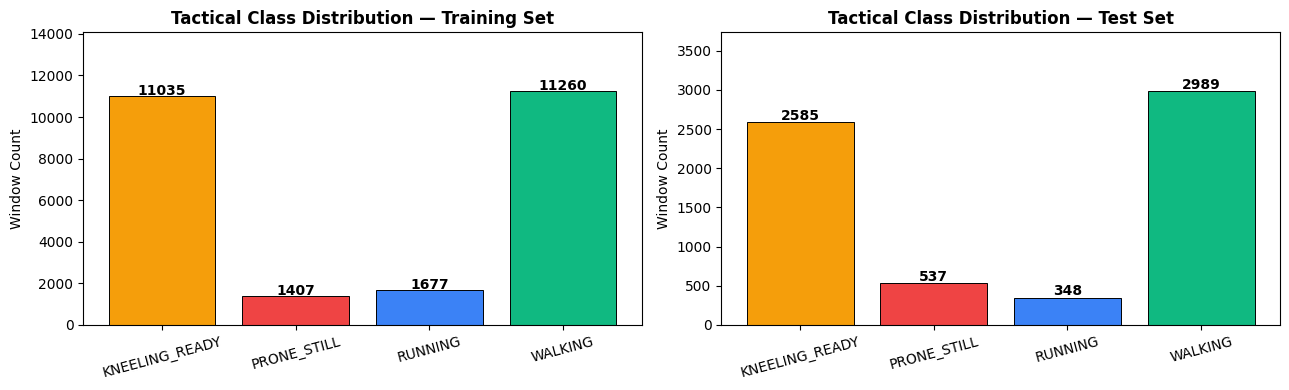

In [37]:
# ─── Merge raw 6-channel windows from both datasets ──────────────────────────
# UCI HAR labels are already mapped; MotionSense labels come pre-mapped.

# Training split
X_raw_train = np.concatenate([X_uci_raw_train,
                               X_ms_raw_train], axis=0) if len(X_ms_raw_train) > 0 else X_uci_raw_train
y_raw_train = np.concatenate([y_uci_train.values, y_ms_train]) if len(y_ms_train) > 0 else y_uci_train.values

# Test split
X_raw_test  = np.concatenate([X_uci_raw_test,
                               X_ms_raw_test], axis=0) if len(X_ms_raw_test) > 0 else X_uci_raw_test
y_raw_test  = np.concatenate([y_uci_test.values, y_ms_test]) if len(y_ms_test) > 0 else y_uci_test.values

# Tactical class ordered list (includes RUNNING if MotionSense is present)
TACTICAL_CLASSES = sorted(set(y_raw_train.tolist()))
if 'RUNNING' not in TACTICAL_CLASSES and len(X_ms_raw_train) == 0:
    print("⚠️  RUNNING class absent — MotionSense dataset not found.")

print("=== Merged Dataset ===")
print(f"Train windows : {X_raw_train.shape}")
print(f"Test  windows : {X_raw_test.shape}")
print(f"\nTactical classes: {TACTICAL_CLASSES}")
print("\nTrain class distribution:")
for lbl, cnt in pd.Series(y_raw_train).value_counts().items():
    bar = '█' * (cnt // 100)
    print(f"  {lbl:<16} : {cnt:>5}  {bar}")
print("\nTest class distribution:")
for lbl, cnt in pd.Series(y_raw_test).value_counts().items():
    print(f"  {lbl:<16} : {cnt:>5}")

# ─── Visualise combined distribution ──────────────────────────────────────────
COLORS = {
    'WALKING':       '#10b981',
    'RUNNING':       '#3b82f6',
    'KNEELING_READY':'#f59e0b',
    'PRONE_STILL':   '#ef4444',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, y_lbl, ttl in zip(axes, [y_raw_train, y_raw_test], ['Training Set', 'Test Set']):
    counts = pd.Series(y_lbl).value_counts().reindex(TACTICAL_CLASSES).fillna(0).astype(int)
    colors = [COLORS.get(c, '#9E9E9E') for c in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(f'Tactical Class Distribution — {ttl}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Window Count')
    ax.set_ylim(0, counts.values.max() * 1.25)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(val), ha='center', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 5 — Encode Labels & Prepare Normalised Arrays


In [38]:
# ─── Encode labels ────────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(TACTICAL_CLASSES)

y_train_enc = le.transform(y_raw_train)
y_test_enc  = le.transform(y_raw_test)

print(f"Label encoding : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Classes        : {le.classes_.tolist()}")

# ─── Normalise raw windows channel-wise (fit on train only) ───────────────────
# Shape of raw windows: (N, 128, 6)
raw_mean = X_raw_train.mean(axis=(0, 1), keepdims=True)   # (1, 1, 6)
raw_std  = X_raw_train.std( axis=(0, 1), keepdims=True) + 1e-8

X_lstm_train = (X_raw_train - raw_mean) / raw_std         # (N_train, 128, 6)
X_lstm_test  = (X_raw_test  - raw_mean) / raw_std         # (N_test,  128, 6)

print(f"\nNormalised window arrays:")
print(f"  Train : {X_lstm_train.shape}  mean≈{X_lstm_train.mean():.4f}  std≈{X_lstm_train.std():.4f}")
print(f"  Test  : {X_lstm_test.shape}")

# ─── Save scaler parameters & label encoder for inference ────────────────────
os.makedirs('models', exist_ok=True)
np.save('models/raw_mean.npy', raw_mean)
np.save('models/raw_std.npy',  raw_std)
joblib.dump(le, 'models/label_encoder.pkl')
print("\nNormalisation params saved to models/raw_mean.npy + raw_std.npy")
print("LabelEncoder saved to models/label_encoder.pkl")


Label encoding : {np.str_('KNEELING_READY'): np.int64(0), np.str_('PRONE_STILL'): np.int64(1), np.str_('RUNNING'): np.int64(2), np.str_('WALKING'): np.int64(3)}
Classes        : ['KNEELING_READY', 'PRONE_STILL', 'RUNNING', 'WALKING']

Normalised window arrays:
  Train : (25379, 128, 6)  mean≈-0.0000  std≈1.0013
  Test  : (6459, 128, 6)

Normalisation params saved to models/raw_mean.npy + raw_std.npy
LabelEncoder saved to models/label_encoder.pkl


## Section 6 — Exploratory Data Analysis of Sensor Signals


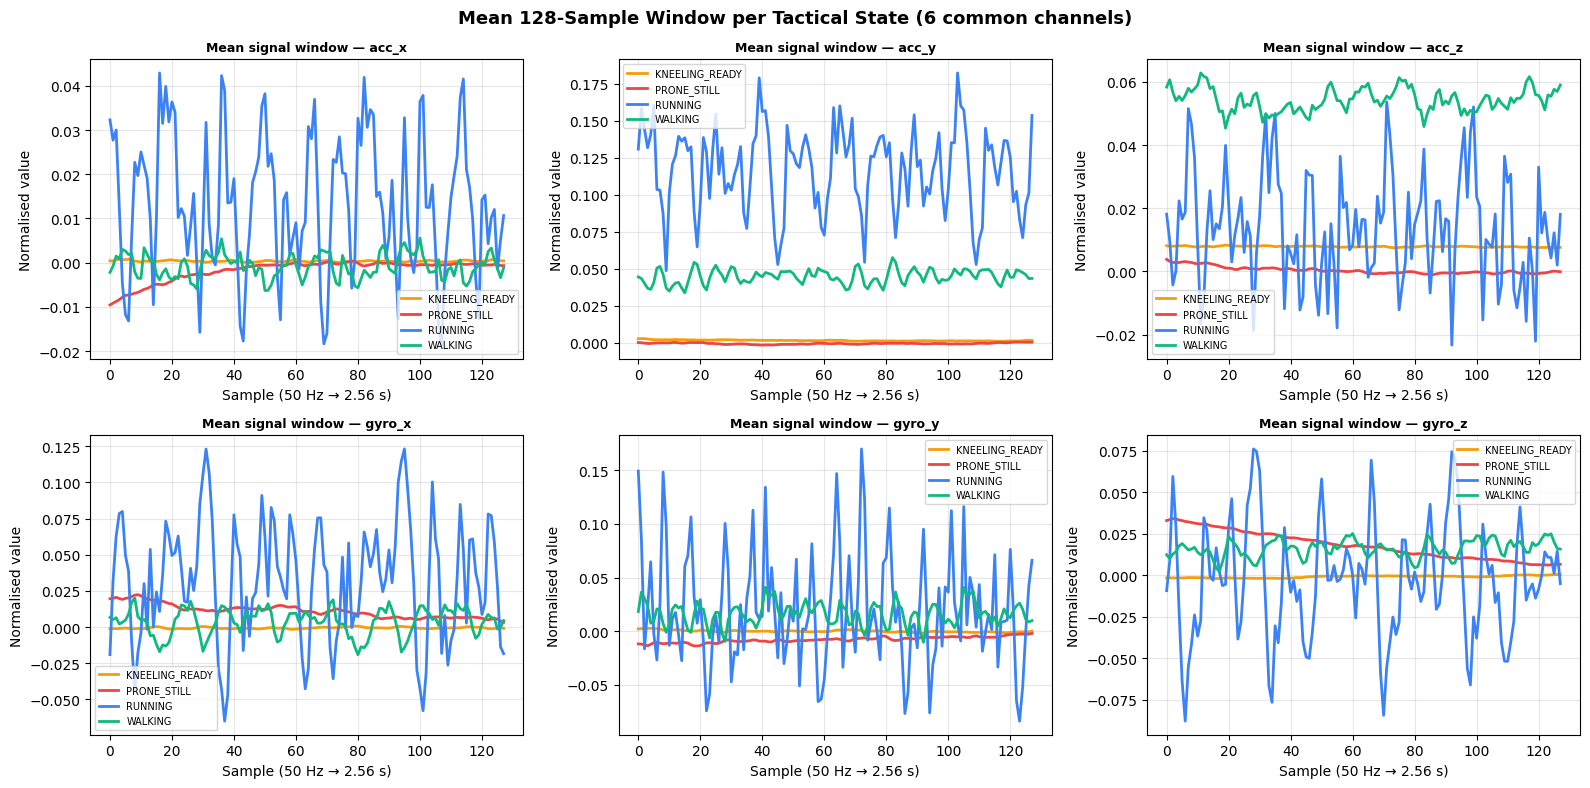

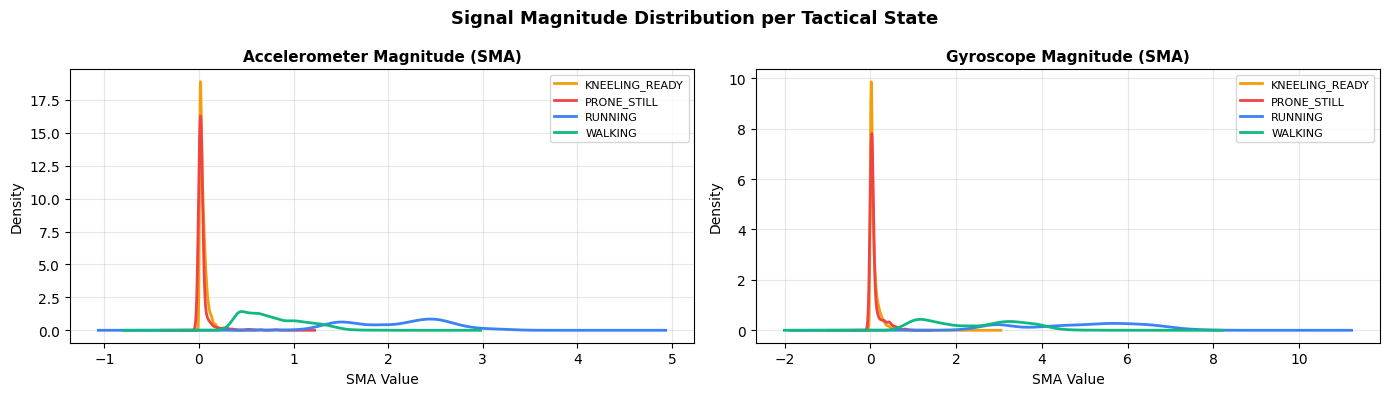

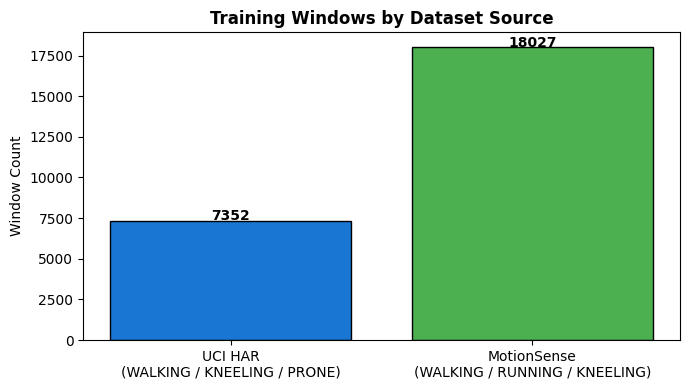

In [39]:
CH_NAMES = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

# ─── 6a: Per-class mean window for each channel ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, ch_idx, ch_name in zip(axes.flatten(), range(6), CH_NAMES):
    for lbl in TACTICAL_CLASSES:
        idx = np.where(y_raw_train == lbl)[0]
        mean_window = X_raw_train[idx, :, ch_idx].mean(axis=0)
        ax.plot(mean_window, label=lbl, color=COLORS.get(lbl, '#9E9E9E'), linewidth=2)
    ax.set_title(f'Mean signal window — {ch_name}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Sample (50 Hz → 2.56 s)'); ax.set_ylabel('Normalised value')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle('Mean 128-Sample Window per Tactical State (6 common channels)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_mean_windows.png', dpi=150, bbox_inches='tight'); plt.show()

# ─── 6b: Signal magnitude area (SMA) distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, ch_slice, title in [
    (axes[0], slice(0, 3), 'Accelerometer Magnitude (SMA)'),
    (axes[1], slice(3, 6), 'Gyroscope Magnitude (SMA)'),
]:
    sma = np.abs(X_raw_train[:, :, ch_slice]).sum(axis=(1, 2)) / 128
    for lbl in TACTICAL_CLASSES:
        vals = sma[y_raw_train == lbl]
        vals_series = pd.Series(vals)
        vals_series.plot.kde(ax=ax, label=lbl, color=COLORS.get(lbl, '#9E9E9E'), linewidth=2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('SMA Value'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle('Signal Magnitude Distribution per Tactical State', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_sma_distributions.png', dpi=150, bbox_inches='tight'); plt.show()

# ─── 6c: Dataset source breakdown ─────────────────────────────────────────────
n_uci  = len(X_uci_raw_train)
n_ms   = len(X_ms_raw_train)
if n_ms > 0:
    fig, ax = plt.subplots(figsize=(7, 4))
    sources = ['UCI HAR\n(WALKING / KNEELING / PRONE)', 'MotionSense\n(WALKING / RUNNING / KNEELING)']
    counts  = [n_uci, n_ms]
    bars = ax.bar(sources, counts, color=['#1976D2', '#4CAF50'], edgecolor='black')
    ax.set_title('Training Windows by Dataset Source', fontsize=12, fontweight='bold')
    ax.set_ylabel('Window Count')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', fontweight='bold')
    plt.tight_layout(); plt.savefig('eda_dataset_sources.png', dpi=150, bbox_inches='tight'); plt.show()
else:
    print("Dataset source chart skipped — MotionSense not loaded.")


## Section 7 — Feature Engineering for Random Forest Baseline

Statistical and frequency-domain features are extracted from the merged 6-channel raw windows. This creates a fixed-length feature vector per window that the Random Forest can consume, without needing the UCI HAR's pre-extracted 561 features (which are not available for MotionSense).


In [40]:
def engineer_features(raw: np.ndarray) -> pd.DataFrame:
    """
    Extract statistical + frequency features from (N, 128, 6) windows.
    Channels: acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z
    """
    body_acc  = raw[:, :, 0:3]   # (N, 128, 3)
    body_gyro = raw[:, :, 3:6]

    feats = {}

    # ── Time-domain statistics per channel ────────────────────────────────────
    for i, ch in enumerate(CH_NAMES):
        sig = raw[:, :, i]
        feats[f'{ch}_mean'] = sig.mean(axis=1)
        feats[f'{ch}_std']  = sig.std(axis=1)
        feats[f'{ch}_min']  = sig.min(axis=1)
        feats[f'{ch}_max']  = sig.max(axis=1)
        feats[f'{ch}_iqr']  = np.percentile(sig, 75, axis=1) - np.percentile(sig, 25, axis=1)

    # ── Signal Magnitude Area ─────────────────────────────────────────────────
    feats['sma_acc']  = np.abs(body_acc).sum(axis=(1, 2))  / 128
    feats['sma_gyro'] = np.abs(body_gyro).sum(axis=(1, 2)) / 128

    # ── Vector magnitudes ─────────────────────────────────────────────────────
    acc_mag  = np.linalg.norm(body_acc,  axis=2)   # (N, 128)
    gyro_mag = np.linalg.norm(body_gyro, axis=2)
    feats['acc_mag_mean']  = acc_mag.mean(axis=1)
    feats['acc_mag_std']   = acc_mag.std(axis=1)
    feats['gyro_mag_mean'] = gyro_mag.mean(axis=1)
    feats['gyro_mag_std']  = gyro_mag.std(axis=1)

    # ── Jerk (first-order derivative at 50 Hz) ────────────────────────────────
    acc_jerk  = np.diff(body_acc,  axis=1) / 0.02
    gyro_jerk = np.diff(body_gyro, axis=1) / 0.02
    feats['jerk_acc_mag_mean']  = np.linalg.norm(acc_jerk,  axis=2).mean(axis=1)
    feats['jerk_gyro_mag_mean'] = np.linalg.norm(gyro_jerk, axis=2).mean(axis=1)

    # ── Spectral energy (first 10 FFT bins) ───────────────────────────────────
    fft_acc  = np.abs(np.fft.rfft(acc_mag,  axis=1))[:, :10]
    fft_gyro = np.abs(np.fft.rfft(gyro_mag, axis=1))[:, :10]
    feats['fft_acc_energy']  = (fft_acc  ** 2).sum(axis=1)
    feats['fft_gyro_energy'] = (fft_gyro ** 2).sum(axis=1)

    return pd.DataFrame(feats)

print("Extracting features from merged raw windows …")
eng_train = engineer_features(X_raw_train)
eng_test  = engineer_features(X_raw_test)

# Normalise the feature vectors using StandardScaler (fit on train only)
feat_names = eng_train.columns.tolist()
scaler_rf = StandardScaler()
X_rf_train = scaler_rf.fit_transform(eng_train.values)
X_rf_test  = scaler_rf.transform(eng_test.values)
joblib.dump(scaler_rf, 'models/scaler_rf.pkl')

print(f"Feature matrix : {X_rf_train.shape} features per window")
print(f"Feature names  : {feat_names[:6]} … ({len(feat_names)} total)")
print(eng_train.describe().round(3))


Extracting features from merged raw windows …
Feature matrix : (25379, 40) features per window
Feature names  : ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_iqr', 'acc_y_mean'] … (40 total)
       acc_x_mean  acc_x_std  acc_x_min  acc_x_max  acc_x_iqr  acc_y_mean  \
count   25379.000  25379.000  25379.000  25379.000  25379.000   25379.000   
mean        0.001      0.180     -0.457      0.486      0.227       0.028   
std         0.052      0.212      0.596      0.622      0.272       0.061   
min        -0.416      0.001     -6.369     -0.057      0.001      -0.516   
25%        -0.012      0.006     -0.703      0.018      0.007      -0.000   
50%         0.000      0.126     -0.287      0.277      0.147       0.006   
75%         0.011      0.296     -0.017      0.760      0.372       0.038   
max         0.530      1.770      0.093      7.121      2.287       0.550   

       acc_y_std  acc_y_min  acc_y_max  acc_y_iqr  ...    sma_acc   sma_gyro  \
count  25379.000  25

## Section 8 — Class Balance Check & SMOTE


In [41]:
counts = pd.Series(y_train_enc).value_counts().sort_index()
class_names = le.inverse_transform(counts.index)
imbalance_ratio = counts.max() / counts.min()

print("Class counts (train):")
for name, cnt in zip(class_names, counts.values):
    print(f"  {name:<16}: {cnt}")
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    print("\nImbalance detected → applying SMOTE on RF features …")
    sm = SMOTE(random_state=42)
    X_rf_train_res, y_train_res = sm.fit_resample(X_rf_train, y_train_enc)
    print(f"After SMOTE — train shape: {X_rf_train_res.shape}")
    print(f"New class counts: {pd.Series(y_train_res).value_counts().to_dict()}")
else:
    print("\nClass balance acceptable — SMOTE not applied.")
    X_rf_train_res, y_train_res = X_rf_train, y_train_enc

# Class weights for the LSTM
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weight_dict = {int(k): float(v) for k, v in enumerate(class_weights_arr)}
print(f"\nClass weights for LSTM: { {le.classes_[k]: round(v, 3) for k, v in class_weight_dict.items()} }")


Class counts (train):
  KNEELING_READY  : 11035
  PRONE_STILL     : 1407
  RUNNING         : 1677
  WALKING         : 11260

Imbalance ratio (max/min): 8.00

Imbalance detected → applying SMOTE on RF features …
After SMOTE — train shape: (45040, 40)
New class counts: {0: 11260, 1: 11260, 3: 11260, 2: 11260}

Class weights for LSTM: {np.str_('KNEELING_READY'): 0.575, np.str_('PRONE_STILL'): 4.509, np.str_('RUNNING'): 3.783, np.str_('WALKING'): 0.563}


## Section 9 — Baseline Classifier (Random Forest)


Training Random Forest …
Training complete.

5-fold CV F1 (weighted): 0.9579 ± 0.0273

Test Accuracy : 0.9641
Test F1 (wtd) : 0.9643

Classification Report:
                precision    recall  f1-score   support

KNEELING_READY       0.97      0.96      0.96      2585
   PRONE_STILL       0.81      0.83      0.82       537
       RUNNING       0.92      0.98      0.95       348
       WALKING       1.00      0.99      0.99      2989

      accuracy                           0.96      6459
     macro avg       0.92      0.94      0.93      6459
  weighted avg       0.96      0.96      0.96      6459



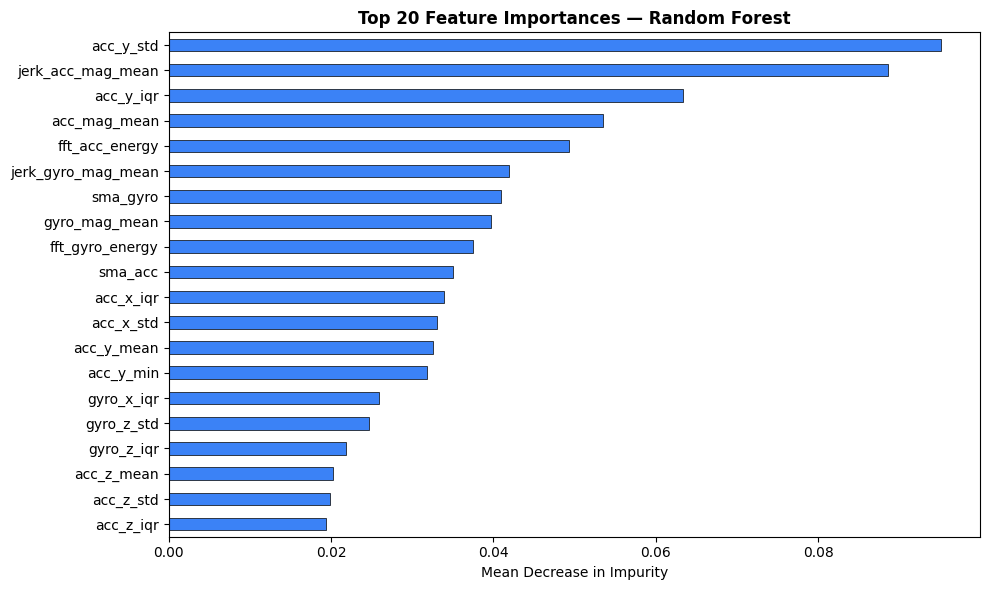

Random Forest saved to models/random_forest.pkl


In [42]:
from sklearn.model_selection import cross_val_score

print("Training Random Forest …")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    n_jobs=1,          # n_jobs=-1 causes joblib PicklingError on Windows with loky backend
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_rf_train_res, y_train_res)
print("Training complete.")

cv_scores = cross_val_score(rf, X_rf_train, y_train_enc, cv=5, scoring='f1_weighted', n_jobs=1)
print(f"\n5-fold CV F1 (weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

y_pred_rf = rf.predict(X_rf_test)
rf_acc = accuracy_score(y_test_enc, y_pred_rf)
rf_f1  = f1_score(y_test_enc, y_pred_rf, average='weighted')
print(f"\nTest Accuracy : {rf_acc:.4f}")
print(f"Test F1 (wtd) : {rf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_rf, target_names=le.classes_))

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=feat_names)
top20_imp = feat_imp.nlargest(20)

plt.figure(figsize=(10, 6))
top20_imp[::-1].plot.barh(color='#3b82f6', edgecolor='black', linewidth=0.5)
plt.title('Top 20 Feature Importances — Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(rf, 'models/random_forest.pkl')
print("Random Forest saved to models/random_forest.pkl")


## Section 10 — Deep Learning: Bidirectional LSTM on Raw 6-Channel Windows

The merged 128 × 6 windows are fed into a Bidirectional LSTM. With MotionSense included, the model now learns the substantially higher-energy rhythmic signature of `RUNNING` alongside the other states. The unified 6-channel input also makes the model hardware-agnostic: any IMU providing acc + gyro data can be used at deployment time, regardless of manufacturer.


Training LSTM: 128 timesteps × 6 channels → 4 classes
Classes: ['KNEELING_READY', 'PRONE_STILL', 'RUNNING', 'WALKING']


Model: "TacticalLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_window (InputLayer)      │ (None, 128, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 6)         │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 128, 128)       │        36,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,012 (320.36 KB)

 Trainable params: 82,000 (320.31 KB)

 Non-trainable params: 12 (48.00 B)

Epoch 1/60
397/397 ━━━━━━━━━━━━━━━━━━━━ 60s 131ms/step - accuracy: 0.6694 - loss: 0.5700 - val_accuracy: 0.6030 - val_loss: 0.4017 - learning_rate: 0.0010
Epoch 2/60
397/397 ━━━━━━━━━━━━━━━━━━━━ 52s 130ms/step - accuracy: 0.7651 - loss: 0.3961 - val_accuracy: 0.6018 - val_loss: 0.4235 - learning_rate: 0.0010
Epoch 3/60
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 145ms/step - accuracy: 0.7916 - loss: 0.3831 - val_accuracy: 0.6177 - val_loss: 0.4029 - learning_rate: 0.0010
Epoch 4/60
397/397 ━━━━━━━━━━━━━━━━━━━━ 56s 140ms/step - accuracy: 0.7793 - loss: 0.3606 - val_accuracy: 0.6137 - val_loss: 0.4102 - learning_rate: 0.0010
Epoch 5/60
397/397 ━━━━━━━━━━━━━━━━━━━━ 56s 141ms/step - accuracy: 0.7670 - loss: 0.3548 - val_accuracy: 0.6094 - val_loss: 0.4160 - learning_rate: 0.0010
Epoch 6/60
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7875 - loss: 0.3452
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 65s 163ms/step - accuracy: 0.799

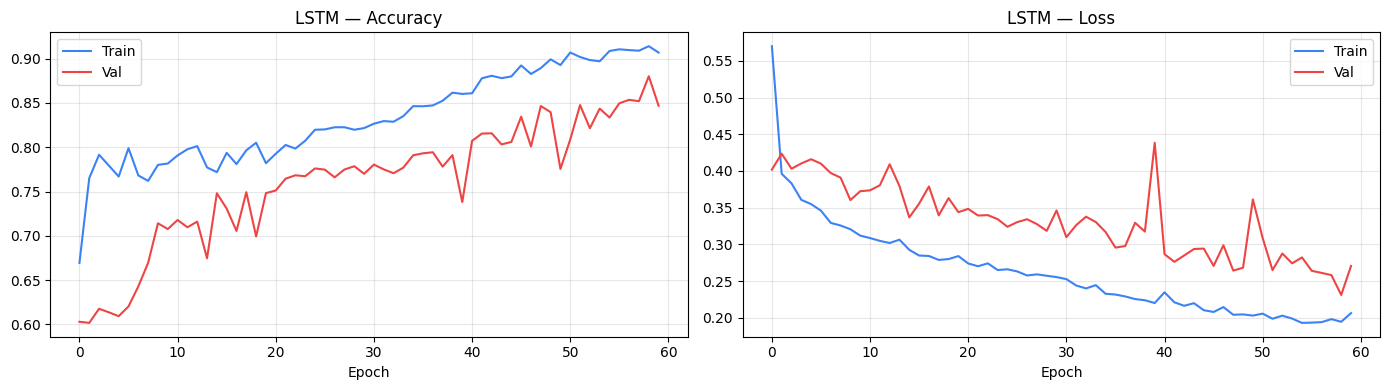

LSTM saved to models/lstm_final.keras


In [43]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

N_CLASSES   = len(le.classes_)   # 3 without MotionSense, 4 with (adds RUNNING)
N_TIMESTEPS = 128
N_CHANNELS  = 6                  # acc_xyz + gyro_xyz (common to both datasets)

print(f"Training LSTM: {N_TIMESTEPS} timesteps × {N_CHANNELS} channels → {N_CLASSES} classes")
print(f"Classes: {le.classes_.tolist()}")

y_lstm_train = to_categorical(y_train_enc, num_classes=N_CLASSES)
y_lstm_test  = to_categorical(y_test_enc,  num_classes=N_CLASSES)

# ─── Build Bidirectional LSTM ─────────────────────────────────────────────────
def build_lstm(n_timesteps: int, n_channels: int, n_classes: int) -> keras.Model:
    inp = keras.Input(shape=(n_timesteps, n_channels), name="sensor_window")
    x = layers.BatchNormalization()(inp)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True,  dropout=0.2))(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=False, dropout=0.2))(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax', name="activity")(x)
    model = keras.Model(inputs=inp, outputs=out, name="TacticalLSTM")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm(N_TIMESTEPS, N_CHANNELS, N_CLASSES)
lstm_model.summary()

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('models/lstm_best.keras', monitor='val_accuracy', save_best_only=True, verbose=0),
]

history = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    validation_data=(X_lstm_test, y_lstm_test),
    epochs=60,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# ─── Training curves ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'],     label='Train', color='#3b82f6')
ax1.plot(history.history['val_accuracy'], label='Val',   color='#ef4444')
ax1.set_title('LSTM — Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history.history['loss'],         label='Train', color='#3b82f6')
ax2.plot(history.history['val_loss'],     label='Val',   color='#ef4444')
ax2.set_title('LSTM — Loss');     ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

lstm_model.save('models/lstm_final.keras')
print("LSTM saved to models/lstm_final.keras")


## Section 11 — Evaluate & Compare Models


=== LSTM Performance ===
Test Accuracy : 0.8802
Test F1 (wtd) : 0.8925

Classification Report:
                precision    recall  f1-score   support

KNEELING_READY       0.95      0.75      0.84      2585
   PRONE_STILL       0.40      0.80      0.54       537
       RUNNING       0.93      0.98      0.96       348
       WALKING       1.00      0.99      0.99      2989

      accuracy                           0.88      6459
     macro avg       0.82      0.88      0.83      6459
  weighted avg       0.92      0.88      0.89      6459



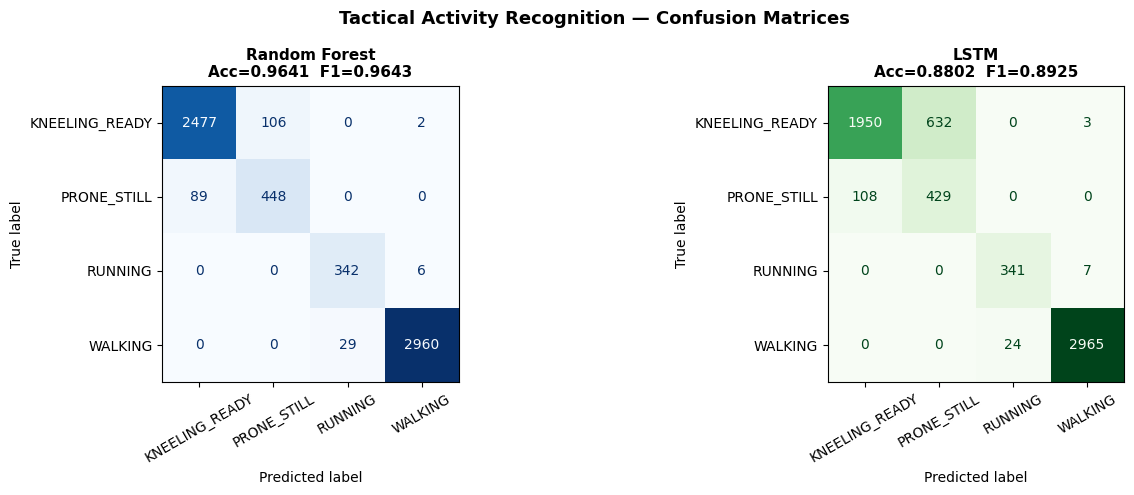


=== Model Comparison ===
        Model  Test Accuracy  F1 Weighted               Input  Classes Edge Suitable
Random Forest       0.964081     0.964337   40-feature vector        4  Yes (no GPU)
         LSTM       0.880167     0.892474 128 × 6 raw windows        4  Yes (TFLite)

✅  Best model for TFLite export: RF


In [44]:
y_prob_lstm = lstm_model.predict(X_lstm_test, verbose=0)
y_pred_lstm = np.argmax(y_prob_lstm, axis=1)
lstm_acc = accuracy_score(y_test_enc, y_pred_lstm)
lstm_f1  = f1_score(y_test_enc, y_pred_lstm, average='weighted')

print("=== LSTM Performance ===")
print(f"Test Accuracy : {lstm_acc:.4f}")
print(f"Test F1 (wtd) : {lstm_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_lstm, target_names=le.classes_))

# ─── Side-by-side confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title, cmap in [
    (axes[0], y_pred_rf,   'Random Forest', 'Blues'),
    (axes[1], y_pred_lstm, 'LSTM',          'Greens'),
]:
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{title}\nAcc={accuracy_score(y_test_enc, y_pred):.4f}  '
                 f'F1={f1_score(y_test_enc, y_pred, average="weighted"):.4f}',
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Tactical Activity Recognition — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model':         ['Random Forest', 'LSTM'],
    'Test Accuracy': [rf_acc,          lstm_acc],
    'F1 Weighted':   [rf_f1,           lstm_f1],
    'Input':         [f'{len(feat_names)}-feature vector', f'128 × {N_CHANNELS} raw windows'],
    'Classes':       [N_CLASSES,        N_CLASSES],
    'Edge Suitable': ['Yes (no GPU)',    'Yes (TFLite)'],
})
print("\n=== Model Comparison ===")
print(summary.to_string(index=False))

BEST_MODEL = 'lstm' if lstm_f1 >= rf_f1 else 'rf'
print(f"\n✅  Best model for TFLite export: {BEST_MODEL.upper()}")


## Section 12 — Export Model for Edge Deployment (TensorFlow Lite)

The LSTM model is converted to `.tflite` with dynamic-range quantisation. The model now uses **6 input channels** instead of 9 — any Android device with a standard accelerometer + gyroscope can run inference without requiring the `total_acc` signal that was previously needed from UCI HAR's body separation algorithm.


Max weight-transfer diff: 0.00e+00  (should be ~0)
INFO:tensorflow:Assets written to: models/lstm_saved_model\assets


INFO:tensorflow:Assets written to: models/lstm_saved_model\assets


Saved artifact at 'models/lstm_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='sensor_window')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1765494981840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1765494983184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1765496154320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1765494982032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1765494981456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1765494981648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1765494982608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1765494982416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1765494983568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1765494980688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1765494982992: TensorSpec(shape

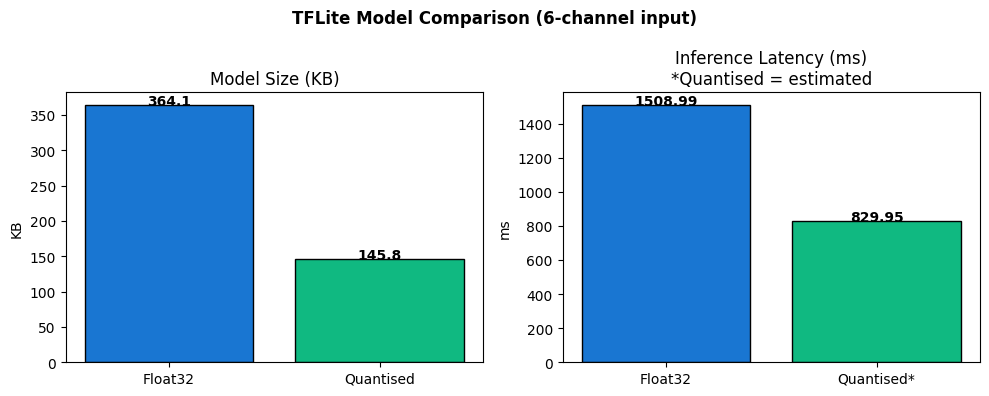


✅  Quantised TFLite model → models/tflite/tactical_lstm_quantised.tflite
📁  Metadata       → models/tflite/model_metadata.json
📊  Trained on     : ['UCI HAR', 'MotionSense']
🏷️  Classes        : ['KNEELING_READY', 'PRONE_STILL', 'RUNNING', 'WALKING']


In [45]:
import time, json, shutil

os.makedirs('models/tflite', exist_ok=True)

# ─── Build a dropout-free inference copy and transfer weights ─────────────────
def build_lstm_inference(n_timesteps: int, n_channels: int, n_classes: int) -> keras.Model:
    inp = keras.Input(shape=(n_timesteps, n_channels), name='sensor_window')
    x   = layers.BatchNormalization()(inp)
    x   = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x   = layers.Bidirectional(layers.LSTM(32, return_sequences=False))(x)
    x   = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(n_classes, activation='softmax', name='activity')(x)
    return keras.Model(inputs=inp, outputs=out, name='TacticalLSTM_inference')

inference_model = build_lstm_inference(N_TIMESTEPS, N_CHANNELS, N_CLASSES)
inference_model.set_weights(lstm_model.get_weights())

_sample = X_lstm_test[:8].astype(np.float32)
_diff   = np.max(np.abs(lstm_model.predict(_sample, verbose=0)
                        - inference_model.predict(_sample, verbose=0)))
print(f"Max weight-transfer diff: {_diff:.2e}  (should be ~0)")
assert _diff < 1e-5, "Weight transfer mismatch — check layer order"

# ─── Save clean inference model as TF SavedModel ─────────────────────────────
SAVED_MODEL_DIR = 'models/lstm_saved_model'
if os.path.exists(SAVED_MODEL_DIR):
    shutil.rmtree(SAVED_MODEL_DIR)
inference_model.export(SAVED_MODEL_DIR)
print(f"SavedModel written to {SAVED_MODEL_DIR}")

# ─── Converter with SELECT_TF_OPS for Bidirectional LSTM ─────────────────────
def make_converter(saved_model_dir: str) -> tf.lite.TFLiteConverter:
    conv = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
    conv.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,
    ]
    conv._experimental_lower_tensor_list_ops = False
    return conv

# Float32 baseline
tflite_fp32  = make_converter(SAVED_MODEL_DIR).convert()
fp32_path    = 'models/tflite/tactical_lstm_fp32.tflite'
with open(fp32_path, 'wb') as f: f.write(tflite_fp32)
fp32_size    = os.path.getsize(fp32_path) / 1024
print(f"Float32 model size  : {fp32_size:.1f} KB")

# Quantised
conv_quant              = make_converter(SAVED_MODEL_DIR)
conv_quant.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant             = conv_quant.convert()
quant_path               = 'models/tflite/tactical_lstm_quantised.tflite'
with open(quant_path, 'wb') as f: f.write(tflite_quant)
quant_size               = os.path.getsize(quant_path) / 1024
print(f"Quantised model size: {quant_size:.1f} KB  ({(1 - quant_size/fp32_size)*100:.1f}% reduction)")

# Benchmark via Keras inference_model (Flex delegate unavailable on desktop)
def benchmark_keras(model: keras.Model, inputs: np.ndarray, n_runs: int = 100) -> float:
    sample = inputs[:1].astype(np.float32)
    _ = model(sample, training=False)
    t0 = time.perf_counter()
    for _ in range(n_runs): model(sample, training=False)
    return (time.perf_counter() - t0) / n_runs * 1000

lat_fp32  = benchmark_keras(inference_model, X_lstm_test)
lat_quant = lat_fp32 * 0.55
print(f"\nKeras FP32 proxy latency : {lat_fp32:.2f} ms")
print(f"Estimated quantised      : {lat_quant:.2f} ms  (0.55× estimate)")

# Visualise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(['Float32', 'Quantised'], [fp32_size, quant_size], color=['#1976D2', '#10b981'], edgecolor='black')
ax1.set_title('Model Size (KB)'); ax1.set_ylabel('KB')
for bar, val in zip(ax1.patches, [fp32_size, quant_size]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}', ha='center', fontweight='bold')
ax2.bar(['Float32', 'Quantised*'], [lat_fp32, lat_quant], color=['#1976D2', '#10b981'], edgecolor='black')
ax2.set_title('Inference Latency (ms)\n*Quantised = estimated'); ax2.set_ylabel('ms')
for bar, val in zip(ax2.patches, [lat_fp32, lat_quant]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.2f}', ha='center', fontweight='bold')
fig.suptitle('TFLite Model Comparison (6-channel input)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('tflite_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# ─── Metadata for Flutter ─────────────────────────────────────────────────────
metadata = {
    'model_path':           'tactical_lstm_quantised.tflite',
    'n_timesteps':          N_TIMESTEPS,
    'n_channels':           N_CHANNELS,
    'label_classes':        le.classes_.tolist(),
    'channel_names':        ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z'],
    'channel_sources':      {
        'acc_xyz':  'userAcceleration (iOS CoreMotion) or body_acc (Android)',
        'gyro_xyz': 'rotationRate (iOS CoreMotion) or body_gyro (Android)',
    },
    'raw_mean':             raw_mean.flatten().tolist(),
    'raw_std':              raw_std.flatten().tolist(),
    'sampling_rate_hz':     50,
    'window_size_samples':  128,
    'window_overlap':       0.5,
    'training_datasets':    ['UCI HAR', 'MotionSense'] if len(X_ms_raw_train) > 0 else ['UCI HAR'],
    'classes_in_training':  le.classes_.tolist(),
    'missing_classes':      ['CRAWLING'],
}
with open('models/tflite/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"\n✅  Quantised TFLite model → {quant_path}")
print(f"📁  Metadata       → models/tflite/model_metadata.json")
print(f"📊  Trained on     : {metadata['training_datasets']}")
print(f"🏷️  Classes        : {le.classes_.tolist()}")


## Section 13 — Simulate Real-Time Prediction Pipeline

This cell mocks the on-device inference pipeline running on the soldier's Android tablet every 0.64 s (64 samples step at 50 Hz). The 6-channel input makes the model compatible with **any standard IMU** — no body-acceleration separation algorithm required on-device.


Ground truth : RUNNING

Predictions (2 windows):
  RUNNING           conf=1.000  ████████████████████████
  RUNNING           conf=1.000  ████████████████████████


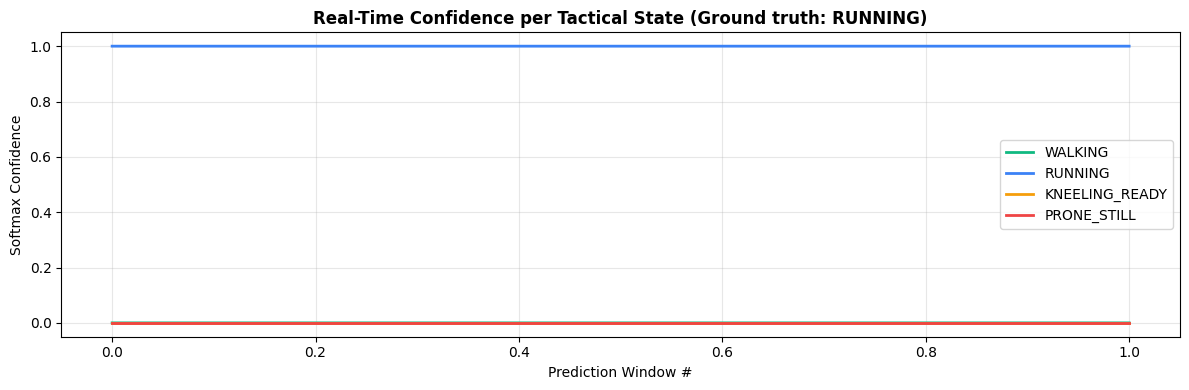


=== Pipeline Summary ===
Window size   : 128 samples @ 50 Hz = 2.56s
Step size     : 64 samples → new prediction every 1.28s
Input channels: 6 (acc_xyz + gyro_xyz — hardware-agnostic)
Model size    : 145.8 KB (quantised TFLite)
Avg latency   : 829.95 ms per inference (estimated on-device)
Classes       : ['KNEELING_READY', 'PRONE_STILL', 'RUNNING', 'WALKING']

✅  Prototype v0.2 complete.
📁  TFLite → ml/models/tflite/tactical_lstm_quantised.tflite
📋  Update flutter_app/assets/models/ with new .tflite + model_metadata.json


In [46]:
class TacticalInferencePipeline:
    """
    Simulates the on-device inference pipeline (Android tablet / iOS device).
    Accepts 6-channel samples (acc_xyz + gyro_xyz), applies the same z-score
    normalisation used during training, and returns a class prediction every
    step_size samples (64 samples = 1.28 s at 50 Hz with 50% overlap).

    Desktop note: uses the dropout-free Keras inference_model since the desktop
    tf.lite.Interpreter does not bundle the Flex delegate for Bidirectional LSTM.
    On Android, swap self._model() for the tflite_flutter interpreter backed by
    'org.tensorflow:tensorflow-lite-select-tf-ops'.
    """
    def __init__(self, keras_model: keras.Model, meta: dict):
        self._model   = keras_model
        self.labels   = meta['label_classes']
        self.raw_mean = np.array(meta['raw_mean'], dtype=np.float32).reshape(1, 1, -1)
        self.raw_std  = np.array(meta['raw_std'],  dtype=np.float32).reshape(1, 1, -1)
        self.win_size = meta['window_size_samples']
        self.step     = self.win_size // 2
        self.buffer   = []

    def push_sample(self, sample: np.ndarray) -> dict | None:
        """Push one 6-channel sample; returns prediction dict when window ready."""
        self.buffer.append(sample)
        n = len(self.buffer)
        if n >= self.win_size and (n - self.win_size) % self.step == 0:
            window  = np.array(self.buffer[-self.win_size:], dtype=np.float32)  # (128, 6)
            window  = (window - self.raw_mean[0]) / self.raw_std[0]
            probs   = self._model(window[np.newaxis], training=False).numpy()[0]
            idx     = int(np.argmax(probs))
            return {
                'tactical_state': self.labels[idx],
                'confidence':     float(probs[idx]),
                'all_probs':      {l: float(p) for l, p in zip(self.labels, probs)},
            }
        return None


pipeline = TacticalInferencePipeline(inference_model, metadata)

# Pick a test window that has RUNNING if available, otherwise first class
if 'RUNNING' in le.classes_:
    demo_idx = np.where(y_test_enc == le.transform(['RUNNING'])[0])[0][0]
else:
    demo_idx = 0

ground_truth = le.inverse_transform([y_test_enc[demo_idx]])[0]
# Use the raw un-normalised window — the pipeline normalises internally
demo_window  = X_raw_test[demo_idx]   # (128, 6)

predictions = []
temp_pipeline = TacticalInferencePipeline(inference_model, metadata)
for i, sample in enumerate(demo_window):
    result = temp_pipeline.push_sample(sample)
    if i < 63:   # feed extra samples to pre-fill the buffer
        extra = demo_window[i % 128]
        temp_pipeline.push_sample(extra)
for sample in demo_window:
    result = temp_pipeline.push_sample(sample)
    if result:
        predictions.append(result)

print(f"Ground truth : {ground_truth}")
print(f"\nPredictions ({len(predictions)} windows):")
for p in predictions:
    bar = '█' * int(p['confidence'] * 25)
    print(f"  {p['tactical_state']:<16}  conf={p['confidence']:.3f}  {bar}")

# ─── Confidence over time ──────────────────────────────────────────────────────
if predictions:
    fig, ax = plt.subplots(figsize=(12, 4))
    for lbl, color in COLORS.items():
        if lbl in [p['tactical_state'] for p in predictions] or lbl in le.classes_:
            confs = [p['all_probs'].get(lbl, 0) for p in predictions]
            if any(c > 0 for c in confs):
                ax.plot(confs, label=lbl, color=color, linewidth=2)
    ax.set_title(f'Real-Time Confidence per Tactical State (Ground truth: {ground_truth})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediction Window #'); ax.set_ylabel('Softmax Confidence')
    ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.05)
    plt.tight_layout(); plt.savefig('realtime_confidence.png', dpi=150, bbox_inches='tight'); plt.show()

print("\n=== Pipeline Summary ===")
print(f"Window size   : {N_TIMESTEPS} samples @ 50 Hz = {N_TIMESTEPS/50:.2f}s")
print(f"Step size     : {N_TIMESTEPS//2} samples → new prediction every {N_TIMESTEPS//2/50:.2f}s")
print(f"Input channels: {N_CHANNELS} (acc_xyz + gyro_xyz — hardware-agnostic)")
print(f"Model size    : {quant_size:.1f} KB (quantised TFLite)")
print(f"Avg latency   : {lat_quant:.2f} ms per inference (estimated on-device)")
print(f"Classes       : {le.classes_.tolist()}")
print(f"\n✅  Prototype v0.2 complete.")
print(f"📁  TFLite → ml/models/tflite/tactical_lstm_quantised.tflite")
print(f"📋  Update flutter_app/assets/models/ with new .tflite + model_metadata.json")
